# Lab Sheet 2

In [1]:
from header import *

Exercise 1.1

Here we factorise a polynomial in one variable.

In [2]:
x = sp.symbols('x')
f = lambda x : 2*x**4-2222*x**3+224220*x**2-2222000*x+2000000
display(Latex("The roots of the polynomial $f(x)=" + sp.latex(f(x)) + "$ are:"))
display([s[0] for s in sp.solve([f(x)],[x])])


<IPython.core.display.Latex object>

[1, 10, 100, 1000]

Whenever a polynomial 
$ f (x) $ has a root 
$ x =a  $, the term 
$ x -a  $ is a factor of 
$ f (x) $.  This indicates that 
$ f (x) $ should be a multiple of the polynomial 
$ g (x)=(x -1) (x -10) (x -100) (x -1000) $.  However, the coefficient of 
$ x^{4} $ in 
$ f (x) $ is 
$ 2 $, whereas the coefficient of 
$ x^{4} $ in the expansion of 
$ g (x) $ is 
$ 1 $.  Thus, the multiplier must be 
$ 2 $, and we must have
$$ f (x)=2 g (x) =2 (x -1) (x -10) (x -100) (x -1000) $$
Sympy confirms this as follows:


In [10]:
display(sp.factor(f(x)))

2*(x - 1000)*(x - 100)*(x - 10)*(x - 1)

In [ ]:
del x,f

Exercise 1.2

Here we look for the roots of the polynomial $g(x)=x^4-x^3-x^2-x/8+1/64$.  Sympy is able to find the roots, but does not express them in the nicest possible way.

In [5]:
x, y, z = sp.symbols('x y z')

In [6]:
y = x**4-x**3-x**2-x/8+sp.Rational(1,64)
z = 16*x**3-24*x**2-6*x+2
display(Latex('$$ y = ' + sp.latex(y) + ' $$'))
sols0 = sp.solve(y) # Find the roots using sympy
# Here is a nicer form of the roots which we enter by hand
sols1 = [
  (1+sp.sqrt(2))*(1+sp.sqrt(3))/4,
  (1+sp.sqrt(2))*(1-sp.sqrt(3))/4,
  (1-sp.sqrt(2))*(1+sp.sqrt(3))/4,
  (1-sp.sqrt(2))*(1-sp.sqrt(3))/4
]
display(Latex('Roots as calculated by sympy'))
display(Latex('$$ ' + sp.latex(sols0) + ' $$'))
display(Latex('Alternative form'))
display(Latex('$$ ' + sp.latex(sols1) + ' $$'))
display(Latex('Check that the two forms are equivalent'))
display([sp.simplify(sols0[i] - sols1[i]) for i in range(4)])


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

[0, 0, 0, 0]

In [12]:
zs = [sp.simplify(z.subs(x, sols1[i])) for i in range(4)]
display(Latex(
 "The values of $z=" + sp.latex(z) + "$ at the roots of $y$ are: $" + str.join(", ", [sp.latex(z0) for z0 in zs]) + "$"
))


<IPython.core.display.Latex object>

In [55]:
del x,y,z

Exercise 1.3

In [28]:
x = sp.symbols('x')
y = x**3 - 3*x + 1
display(Latex("The roots of $" + sp.latex(y) +"$ are:"))
sols = sp.solve([y])
aa = [x.subs(s) for s in sols]
aa0 = [sp.re(a.evalf()) for a in aa]
for a in aa:
  display(a)
display(Latex("The numerical values of these roots are:"))
display(aa0)

<IPython.core.display.Latex object>

-3/((-1/2 - sqrt(3)*I/2)*(27/2 + 27*sqrt(3)*I/2)**(1/3)) - (-1/2 - sqrt(3)*I/2)*(27/2 + 27*sqrt(3)*I/2)**(1/3)/3

-(-1/2 + sqrt(3)*I/2)*(27/2 + 27*sqrt(3)*I/2)**(1/3)/3 - 3/((-1/2 + sqrt(3)*I/2)*(27/2 + 27*sqrt(3)*I/2)**(1/3))

-(27/2 + 27*sqrt(3)*I/2)**(1/3)/3 - 3/(27/2 + 27*sqrt(3)*I/2)**(1/3)

<IPython.core.display.Latex object>

[0.347296355333861, 1.53208888623796, -1.87938524157182]

We now want to plot $y$ as a function of $x$, for which we need to generate an array called `xs` containing many closely spaced values of $x$, and then evaluate $y$ at all those values of $x$.  The most efficient way to evaluate a sympy expression at many points is to use `sp.lambdify(...,'numpy')` to convert it into a numpy function.  Note that the variable $x$ is the first argument to `sp.lambdify()` and the function $y$ is the second argument.  We use the `fix_axes()` function to ensure that the $x$ and $y$ axes pass through the origin instead of being shown as a box surrounding the whole plot.  This is not a standard Python function, it is made available by the line `from header import *` at the top of this worksheet.

<Axes: >

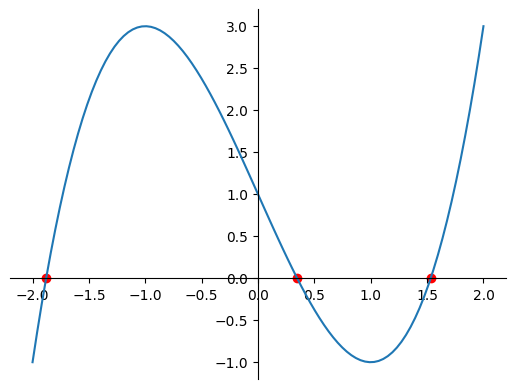

In [29]:
xs = np.linspace(-2,2,100)
ys = sp.lambdify(x, y, 'numpy')(xs)
plt.plot(xs, ys)
plt.scatter(aa0, [0]*len(aa0), color='red')
fix_axes(plt.gca())


The only negative root is $x=-1.879 $ , which is `aa[2]`.  Sympy notation for the gradient $\frac{dy}{dx} $ is `sp.diff(y,x)`.  We can thus find the gradient at the negative root as shown below.  Note that numerical inaccuracies give a tiny imaginary part, which should really be zero.  We can use `sp.re()` to discard the imaginary part.


In [37]:
slope = sp.simplify(sp.expand(sp.diff(y, x).subs({x : aa[2]})))
display(slope)
display(slope.evalf())
display(sp.re(slope.evalf()))

3 + 3*2**(2/3)/(1 + sqrt(3)*I)**(2/3) + 3*2**(1/3)*(1 + sqrt(3)*I)**(2/3)/2

7.59626665871387 - 0.e-22*I

7.59626665871387

In [59]:
del x,y

Exercise 1.4

Here we solve the equation $\frac{b^2-c^2+x(c^2+1)}{c^2x-c^2+1}=x$ for $x$.  The answer depends on the values of $b$ and $c$, and we need some careful arguments to deal with various special cases.

In [60]:
x, b, c = sp.symbols('x b c')
g = lambda x: (b**2 - c**2 + (1 + c**2)*x)/(1 - c**2 + c**2 * x)
display(g(x))

(b**2 - c**2 + x*(c**2 + 1))/(c**2*x - c**2 + 1)

The general solution is as follows:

In [61]:
sols = sp.solve([sp.Eq(g(x),x)],[x])
display(sols[0][0])
display(sols[1][0])



(-b + c)/c

(b + c)/c

The above solutions involve division by $c$, so they do not make sense when $c=0$.  We must therefore check separately what happens when $c=0$.  In that case, $g(x)$ simplifies as follows:

In [62]:
g(x).subs({c : 0})

b**2 + x

The equation $g(x)=x$ thus becomes $x+b^{2}=x$.  This is always true if $b=0$, and never true if $b\neq 0$.

In [63]:
del x,b,c,g

Now return to the case $c\neq 0$.  The two solutions can then be written as $x=1-\frac{b}{c}$ and $x=1+\frac{b}{c}$.  These are the same (and both equal to $1$) if $b=0$, but are different otherwise.

Our conclusion is as follows: 
- If $b=c=0$ then $g(x)=x$ for all $x$.
- If $b=0$ but $c\neq 0$ then the only solution to $g(x)=x$ is $x=1$.
- If $b \neq 0$ but $c=0$ then there are no solutions.
- If $b \neq 0$ and $c\neq 0$ then there are precisely two different solutions, namely $1+\frac{b}{c}$ and $1-\frac{b}{c}$.

Exercise 2.1

Here we look for solutions to $\sin(\pi x + e^{-x})=0$.

In [38]:
x = sp.symbols('x')
f = lambda x: sp.sin(sp.pi * x + sp.exp(-x))

Sympy finds two solutions, which are given in terms of the [Lambert W function](https://en.wikipedia.org/wiki/Lambert_W_function).

In [39]:
sol = sp.solve([f(x)],[x])
for s in sol:
  display(s[0])

LambertW(-exp(-1)/pi) + 1

LambertW(-1/pi)

<Axes: >

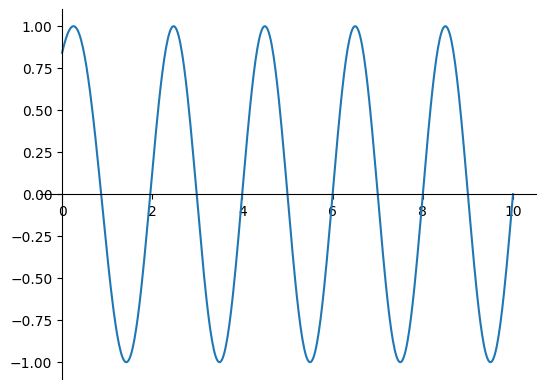

In [40]:
f1 = sp.lambdify(x, f(x), 'numpy')
xs = np.linspace(0,10,500)
ys = f1(xs)
plt.plot(xs, ys)
fix_axes(plt.gca())


The graph looks rather like a sine wave, with roots at $x=1,2,3,4$ and so on.  This makes sense, because as soon as $x$ becomes reasonably large, the term $e^{-x}$ becomes very small, so $f(x)$ is close to $ \sin(\pi x) $.  The positive roots of $\sin(\pi x) $ are exactly $x=1,2,3,4$ and so on, so we expect the roots of $f(x) $ to be approximately the same.

In [42]:
sc.optimize.root_scalar(f1, x0=0).root

-0.5538270366445136

We now find some roots more precisely, using the root-finding function [`sc.optimize.root_scalar()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root_scalar.html) from the scipy package.  That function returns a complex package of information about the root-finding process; if we just want the approximate root itself, we need to enter `sc.optimize.root_scalar(...).root`

In [67]:
roots = np.array([sc.optimize.root_scalar(f1, x0=n).root for n in range(1,11)])
roots

array([0.86612595, 1.95493573, 2.98389499, 3.99413566, 4.99785063,
       5.99921037, 6.99970965, 7.99989321, 8.99996072, 9.99998555])

It turns out that the $n$ th root is very close to the number $r(n)=n-e^{-n}/\pi-e^{-2n}/\pi^2$.  We can express this in Python as follows:

In [68]:
r = lambda n: n - np.exp(-n)/np.pi - np.exp(-2*n)/np.pi**2
roots_approx = np.array([r(n) for n in range(1,11)])
roots_approx

array([0.86918801, 1.95506568, 2.98390113, 3.99413596, 4.99785064,
       5.99921037, 6.99970965, 7.99989321, 8.99996072, 9.99998555])

This is very close to our answer in (b).  We can calculate the differences as follows:

In [69]:
roots - roots_approx

array([-3.06205750e-03, -1.29947773e-04, -6.14382049e-06, -3.00356681e-07,
       -1.48553916e-08, -7.37820471e-10, -3.66995323e-11, -1.82609483e-12,
       -9.05941988e-14, -3.55271368e-15])

In [70]:
del x,f,f1,sol,s,roots,r,roots_approx

Exercise 3.1

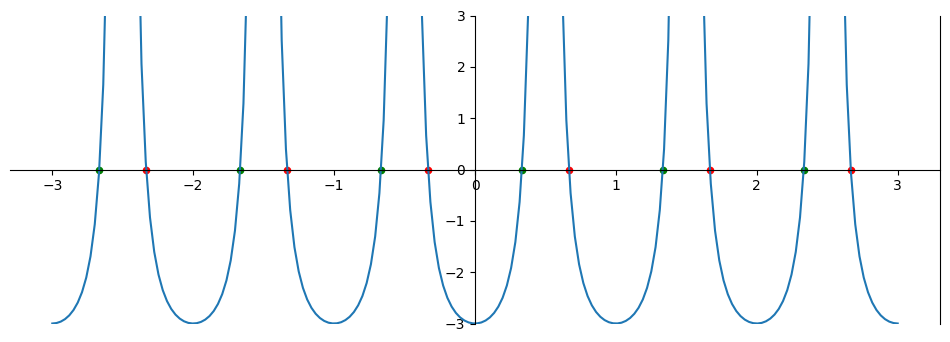

In [71]:
x = sp.symbols('x')
f = lambda x: sp.tan(sp.pi * x) ** 2 - 3
f1 = sp.lambdify(x, f(x), 'numpy')
xs = np.linspace(-3,3,200)
ys = f1(xs)
plt.figure(figsize=(12,4))
plt.plot(xs, ys)
plt.ylim(-3,3)
plt.gca().spines['bottom'].set_position('zero')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_position('zero')
ns = np.arange(-3,3)
plt.scatter(ns + 1/3, 0*ns, color='green', s=20)
plt.scatter(ns + 2/3, 0*ns, color='red', s=20)

The roots are at $ -\frac{8}{3} $,  $ -\frac{7}{3} $,  $ -\frac{5}{3} $,  $ -\frac{4}{3} $,  $ -\frac{2}{3} $,  $ -\frac{1}{3} $,  $ \frac{1}{3} $,  $ \frac{2}{3} $,  $ \frac{4}{3} $, $ \frac{5}{3} $,  $ \frac{7}{3} $,  $ \frac{8}{3} $ and so on.  In other words, for every integer $n$, there is a root at $n-\frac{1}{3}$, and another one at $n+\frac{1}{3}$.

In [72]:
sp.solve(f(x))

[-1/3, 1/3]

In [73]:
sols = sp.solveset(f(x), x, domain=sp.S.Reals)
sols

Union(ImageSet(Lambda(_n, (2*_n*pi - 2*pi/3)/pi), Integers), ImageSet(Lambda(_n, (2*_n*pi + 2*pi/3)/pi), Integers), ImageSet(Lambda(_n, (2*_n*pi - pi/3)/pi), Integers), ImageSet(Lambda(_n, (2*_n*pi + pi/3)/pi), Integers))

In [74]:
sols1 = np.array([s.args[0](n) for n in range(-3,4) for s in sols.args])
sols1 = sols1[(-3 < sols1) & (sols1 < 3)]
sols1


array([-8/3, -4/3, -7/3, -5/3, -2/3, 2/3, -1/3, 1/3, 4/3, 8/3, 5/3, 7/3],
      dtype=object)

In [75]:
del x,f,f1,sols,sols1

Exercise 4.1

Here we solve a system of three linear equations in the variables $x$, $y$ and $z$, and then calculate the value of $x^2+y^2+z^2$ at the solution point.

In [44]:
x, y, z = sp.symbols('x y z')
eqns = [
 sp.Eq(x/2 + y/3 + z/4, 1),
 sp.Eq(x/3 + y/4 + z/5, 2),
 sp.Eq(x/4 + y/5 + z/6, 3)
]
for e in eqns:
  display(e)

Eq(x/2 + y/3 + z/4, 1)

Eq(x/3 + y/4 + z/5, 2)

Eq(x/4 + y/5 + z/6, 3)

In [77]:
sol = sp.solve(eqns)
print(sol)
(x**2 + y**2 + z**2).subs(sol)

{x: 132, y: -600, z: 540}


669024

In [78]:
del x,y,z,eqns,sol

Exercise 4.2

In [79]:
p, q, r, u, v, x, y, z = sp.symbols('p q r u v x y z')

In [80]:
sp.solve([p+q+r, p+2*q+3*r-1])

{p: r - 1, q: 1 - 2*r}

The above answer indicates that $r$ can take any value but then we must have $p=r-1$ and $q=1-2r$.  Thus, there are infinitely many solutions.

In [81]:
sp.solve([u+v-1001, u+2*v-1002, u+3*v-1006])

[]

The above answer indicates that there are no solutions (which is also easily seen by hand).

In [82]:
sp.solve([
 sp.Eq(x +   y +   z, 2),
 sp.Eq(x + 2*y + 3*z, 2),
 sp.Eq(x + 4*y + 9*z, 2)
])

{x: 2, y: 0, z: 0}

This has a unique, fully-determined solution.